# Regresión Logística — Predicción de Respuesta a Oferta Tecnológica
**Materia:** Fundamentos de Aprendizaje de Máquina  
**Dataset:** `demomodifmodern2.xlsx` — 6,400 registros, 28 predictores  
**Variable objetivo:** `respuest` → 1 = compró la oferta, 0 = no compró

---
## Estructura del Notebook
| Sección | Contenido |
|---|---|
| §1 | Carga y EDA |
| §2 | Preprocesamiento (encoding ordinal, binario, OHE) |
| §3 | Modelo **sin balancear** |
| §4 | Modelo **balanceado** (`class_weight='balanced'`) |
| §5 | Modelo **SMOTE** |
| §6 | Comparación de modelos |
| §7 | Interpretación de coeficientes y Odds Ratios |
| §8 | Análisis del umbral de decisión |
| §9 | Validación cruzada estratificada |
| §10 | Resumen conceptual (quiz) |
---

## 0. Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, f1_score, recall_score, precision_score, average_precision_score
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
RANDOM_STATE = 42
print('✓ Librerías cargadas')

✓ Librerías cargadas


## 1. Carga y Exploración de Datos (EDA)

In [1]:
df = pd.read_excel('demomodifmodern2.xlsx')
print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'\nColumnas: {df.columns.tolist()}')
df.head()

Dimensiones: 6400 filas × 29 columnas

Columnas: ['edad', 'marital', 'direcc', 'ingres', 'ingcat', 'coche', 'cochecat', 'educ', 'empleo', 'retirado', 'empcat', 'satlab', 'sexo', 'residen', 'pc', 'internal', 'voz', 'datos', 'internet', 'nacional', 'ilimit', 'tv', 'video', 'stream', 'vod', 'tablet', 'impres', 'noticias', 'respuest']


### 1.1 Distribución de la variable objetivo

> **Hallazgo clave:** El dataset presenta un **desbalance severo de 8.43:1** (89.4% No compró vs 10.6% Compró). Esto justifica plenamente el uso de técnicas de balanceo.

=== DISTRIBUCIÓN DE respuest ===
  No: 5721 (89.4%)
  Sí:  679 (10.6%)

⚠️  Ratio de desbalance: 8.43:1
   → Dataset SEVERAMENTE DESBALANCEADO. Se justifica el uso de técnicas de balanceo.


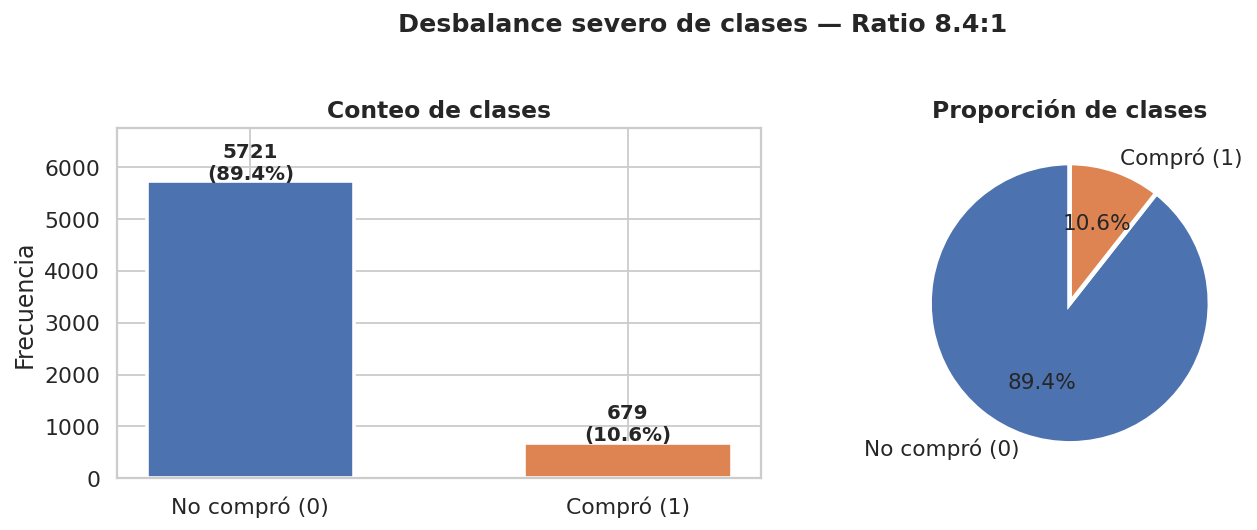

In [1]:
target_counts = df['respuest'].value_counts()
print('=== DISTRIBUCIÓN DE respuest ===')
for val in target_counts.index:
    print(f"  {val}: {target_counts[val]:>5} ({target_counts[val]/len(df)*100:.1f}%)")
ratio = target_counts['No'] / target_counts['Sí']
print(f'\n⚠️  Ratio de desbalance: {ratio:.2f}:1')
print('   → Dataset SEVERAMENTE DESBALANCEADO. Se justifica el uso de técnicas de balanceo.')

### 1.2 Distribución de variables continuas por clase

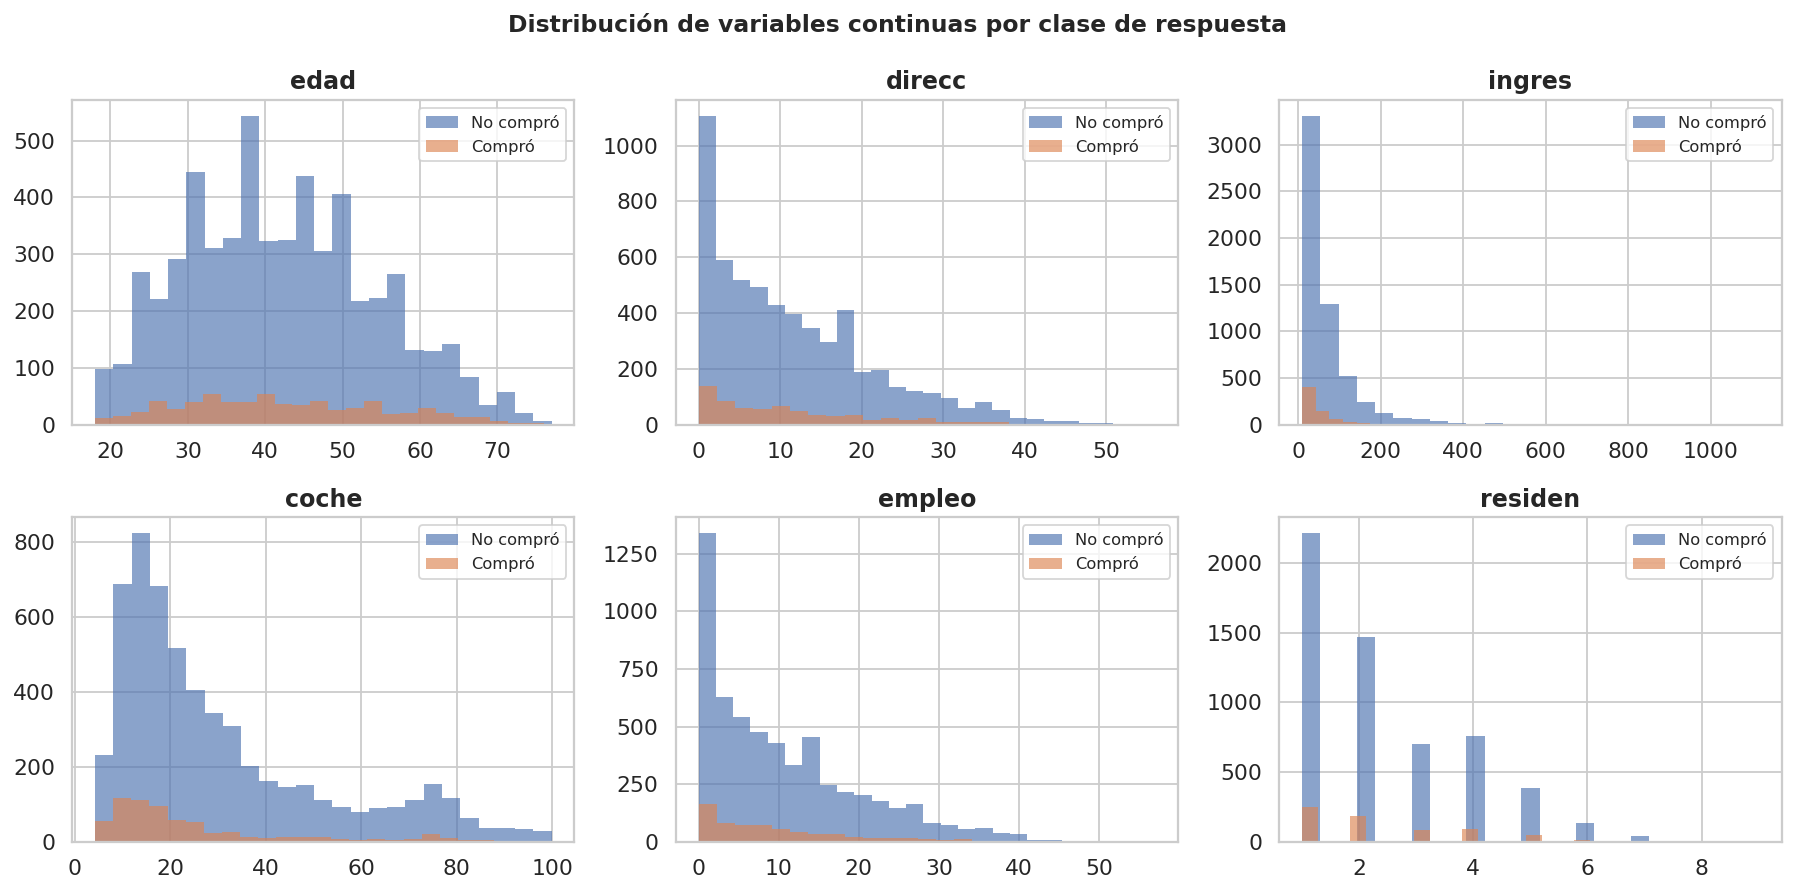

In [1]:
# Histogramas por clase (ver figura)
# Variables numéricas: edad, direcc, ingres, coche, empleo, residen

### 1.3 Tasa de respuesta por variable binaria

> Variables como `internal` (plan internacional) y `pc` muestran tasas de compra notablemente superiores a la media global.

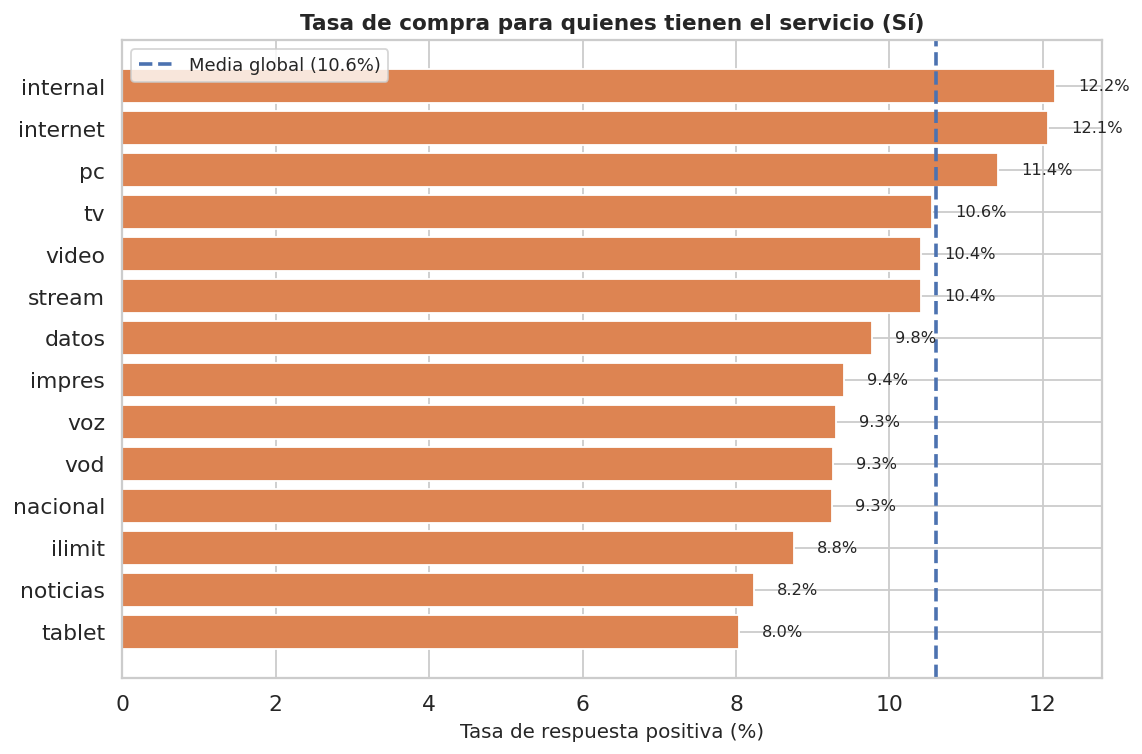

In [1]:
# Tasa de compra para quienes poseen cada servicio/producto

### 1.4 Correlación con la variable objetivo

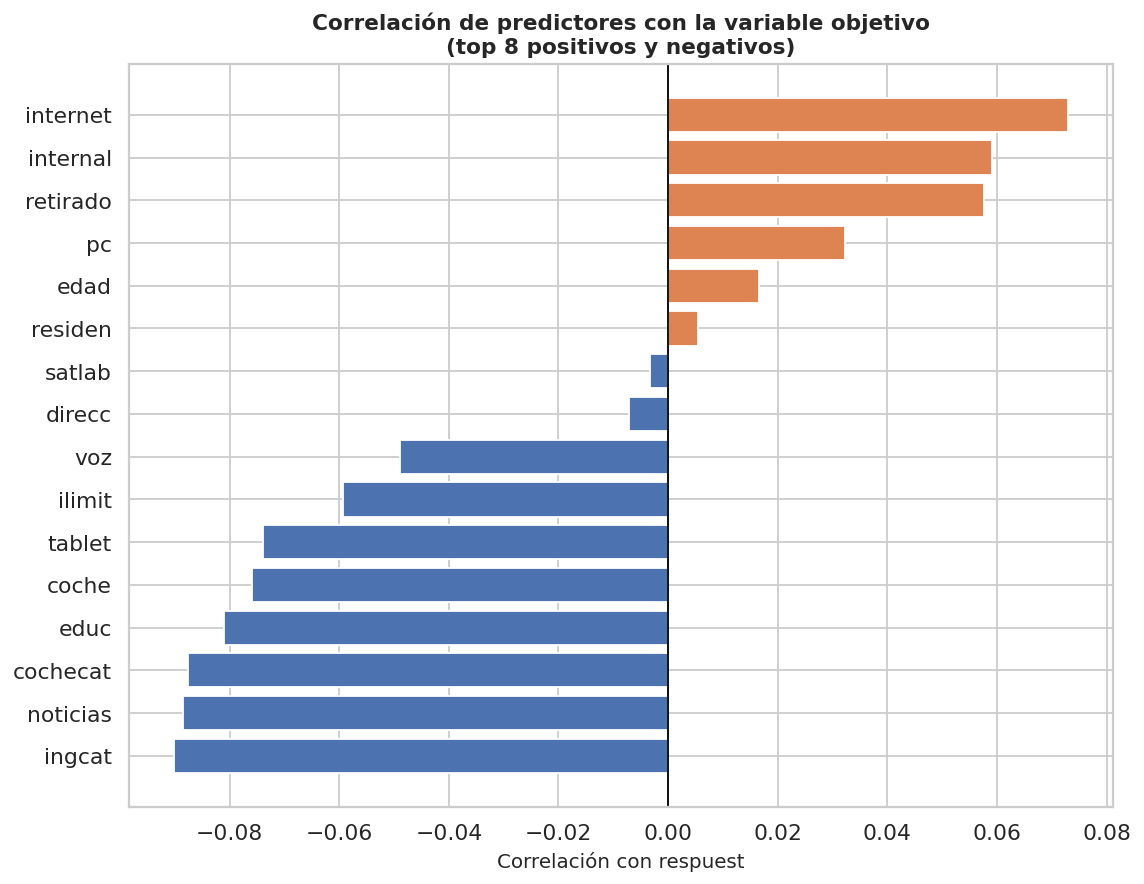

In [1]:
# Variables con mayor correlación (positiva y negativa) con respuest

## 2. Preprocesamiento

### Estrategia de encoding por tipo de variable

| Tipo | Variables | Método |
|------|-----------|--------|
| **Binarias Sí/No** | pc, internal, voz, datos, tv, ... | Mapeado directo: Sí=1, No=0 |
| **Ordinales** | educ, satlab, ingcat, empcat, cochecat | Encoding ordinal respetando el orden natural |
| **Nominales** | marital, sexo | One-Hot Encoding (drop_first=True) |
| **internet** | internet | Sí=1, resto=0 (incluye 'No sabe', 'No contesta') |

In [1]:
# --- Codificación del target ---
df['respuest_bin'] = (df['respuest'] == 'Sí').astype(int)
y = df['respuest_bin']

# --- Encoding de predictores ---
binary_sino = ['retirado','pc','internal','voz','datos','nacional',
               'ilimit','tv','video','stream','vod','tablet','impres','noticias']

ordinal_maps = {
    'ingcat':    {'menos de $25':1, '$25 - $49':2, '$50 - $74':3, '$75+':4},
    'cochecat':  {'Económico':1, 'Estándar':2, 'Lujo':3},
    'educ':      {'No completó el bachillerato':1, 'Bachillerato':2,
                  'Universitarios parciales':3, 'Universitarios':4, 'Post-universitarios':5},
    'empcat':    {'Menos de 5':1, '5 a 15':2, 'Más de 15':3},
    'satlab':    {'Muy insatisfecho':1, 'Algo insatisfecho':2, 'Neutro':3,
                  'Algo satisfecho':4, 'Muy satisfecho':5},
    'internet':  {'No':0, 'No sabe':0, 'No contesta':0, 'Sí':1}
}

X = df.drop(columns=['respuest', 'respuest_bin']).copy()

for col in binary_sino:
    X[col] = (X[col] == 'Sí').astype(int)

for col, mapping in ordinal_maps.items():
    X[col] = X[col].map(mapping)

X = pd.get_dummies(X, columns=['marital', 'sexo'], drop_first=True)

print(f'Shape final de X: {X.shape}')
print(f'Valores faltantes: {X.isnull().sum().sum()}')
print(f'Columnas resultantes: {X.columns.tolist()}')

Shape final de X: (6400, 28)
Valores faltantes: 0
Columnas resultantes: ['edad', 'direcc', 'ingres', 'ingcat', 'coche', 'cochecat', 'educ', 'empleo', 'retirado', 'empcat', 'satlab', 'residen', 'pc', 'internal', 'voz', 'datos', 'internet', 'nacional', 'ilimit', 'tv', 'video', 'stream', 'vod', 'tablet', 'impres', 'noticias', 'marital_Sin casar', 'sexo_Mujer']


In [1]:
# División estratificada 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.4f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.4f}')
print('✓ Estratificación correcta: mismo desbalance en ambos splits')

Train: 4480 muestras  |  Test: 1920 muestras
Proporción clase 1 en train: 0.1063
Proporción clase 1 en test:  0.1063
✓ Estratificación correcta: mismo desbalance en ambos splits


## 3. Modelo Sin Balancear

> **¿Qué esperamos?** Con un desbalance 8.43:1, el modelo aprende a predecir *siempre* la clase mayoritaria (No compró). Obtendrá ~89% de accuracy simplemente sin detectar ningún comprador real.

In [1]:
pipe_unbal = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        solver='lbfgs', max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight=None  # SIN ajuste de clase
    ))
])

pipe_unbal.fit(X_train, y_train)
y_pred_ub = pipe_unbal.predict(X_test)
y_prob_ub = pipe_unbal.predict_proba(X_test)[:, 1]

print('=== REPORTE CLASIFICACIÓN — MODELO SIN BALANCEAR ===')
print(classification_report(y_test, y_pred_ub, target_names=['No compró (0)', 'Compró (1)']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_ub):.4f}')
print()
print('⚠️  OBSERVACIÓN: Accuracy = 89.4% pero Recall(Compró) = 0.00')
print('   El modelo NO detecta a ningún comprador (VP=0, FN=204)')
print('   → La accuracy es una métrica ENGAÑOSA con clases desbalanceadas')

=== REPORTE CLASIFICACIÓN — MODELO SIN BALANCEAR ===
              precision    recall  f1-score   support

No compró (0)       0.89      1.00      0.94      1716
   Compró (1)       0.00      0.00      0.00       204

    accuracy                           0.89      1920
   macro avg       0.45      0.50      0.47      1920
weighted avg       0.80      0.89      0.84      1920

AUC-ROC: 0.6832

⚠️  OBSERVACIÓN: Accuracy = 89.4% pero Recall(Compró) = 0.00
   El modelo NO detecta a ningún comprador (VP=0, FN=204)
   → La accuracy es una métrica ENGAÑOSA con clases desbalanceadas


## 4. Modelo Balanceado — class_weight='balanced'

> **Mecanismo:** Scikit-learn calcula automáticamente pesos inversamente proporcionales a la frecuencia de cada clase:
> $$w_i = \frac{n_{total}}{k \cdot n_i}$$
> En este caso: $w_{No} \approx 0.56$, $w_{Sí} \approx 4.70$. El error de clasificar un comprador se penaliza ~8.4 veces más.

In [1]:
pipe_cw = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        solver='lbfgs', max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'  # BALANCEO POR PESOS
    ))
])

pipe_cw.fit(X_train, y_train)
y_pred_cw = pipe_cw.predict(X_test)
y_prob_cw = pipe_cw.predict_proba(X_test)[:, 1]

# Calcular pesos para mostrar
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
print(f'Peso clase 0 (No compró): {weights[0]:.4f}')
print(f'Peso clase 1 (Compró):    {weights[1]:.4f}')
print(f'Ratio de pesos: {weights[1]/weights[0]:.2f}x (= ratio de desbalance)')
print()
print('=== REPORTE CLASIFICACIÓN — class_weight=balanced ===')
print(classification_report(y_test, y_pred_cw, target_names=['No compró (0)', 'Compró (1)']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_cw):.4f}')

Peso clase 0 (No compró): 0.5593
Peso clase 1 (Compró):    4.7130
Ratio de pesos: 8.43x (= ratio de desbalance)

=== REPORTE CLASIFICACIÓN — class_weight=balanced ===
              precision    recall  f1-score   support

No compró (0)       0.94      0.61      0.74      1716
   Compró (1)       0.16      0.65      0.26       204

    accuracy                           0.61      1920
   macro avg       0.55      0.63      0.50      1920
weighted avg       0.85      0.61      0.69      1920

AUC-ROC: 0.6825


## 5. Modelo Balanceado — SMOTE

> **Mecanismo:** SMOTE (Synthetic Minority Oversampling TEchnique) genera muestras **sintéticas** de la clase minoritaria interpolando entre vecinos más cercanos en el espacio de características. Se aplica **solo en train**, nunca en test.

In [1]:
pipe_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),   # Oversamplea clase minoritaria
    ('lr', LogisticRegression(
        solver='lbfgs', max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

pipe_smote.fit(X_train, y_train)
y_pred_sm = pipe_smote.predict(X_test)
y_prob_sm = pipe_smote.predict_proba(X_test)[:, 1]

print('=== REPORTE CLASIFICACIÓN — SMOTE ===')
print(classification_report(y_test, y_pred_sm, target_names=['No compró (0)', 'Compró (1)']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_prob_sm):.4f}')
print()
print('Nota: SMOTE genera puntos sintéticos SOLO en el conjunto de entrenamiento.')
print('El test set queda intacto con la distribución original.')

=== REPORTE CLASIFICACIÓN — SMOTE ===
              precision    recall  f1-score   support

No compró (0)       0.93      0.61      0.74      1716
   Compró (1)       0.16      0.64      0.26       204

    accuracy                           0.62      1920
   macro avg       0.55      0.62      0.50      1920
weighted avg       0.85      0.62      0.69      1920

AUC-ROC: 0.6751

Nota: SMOTE genera puntos sintéticos SOLO en el conjunto de entrenamiento.
El test set queda intacto con la distribución original.


## 6. Comparación de Modelos

### 6.1 Matrices de Confusión

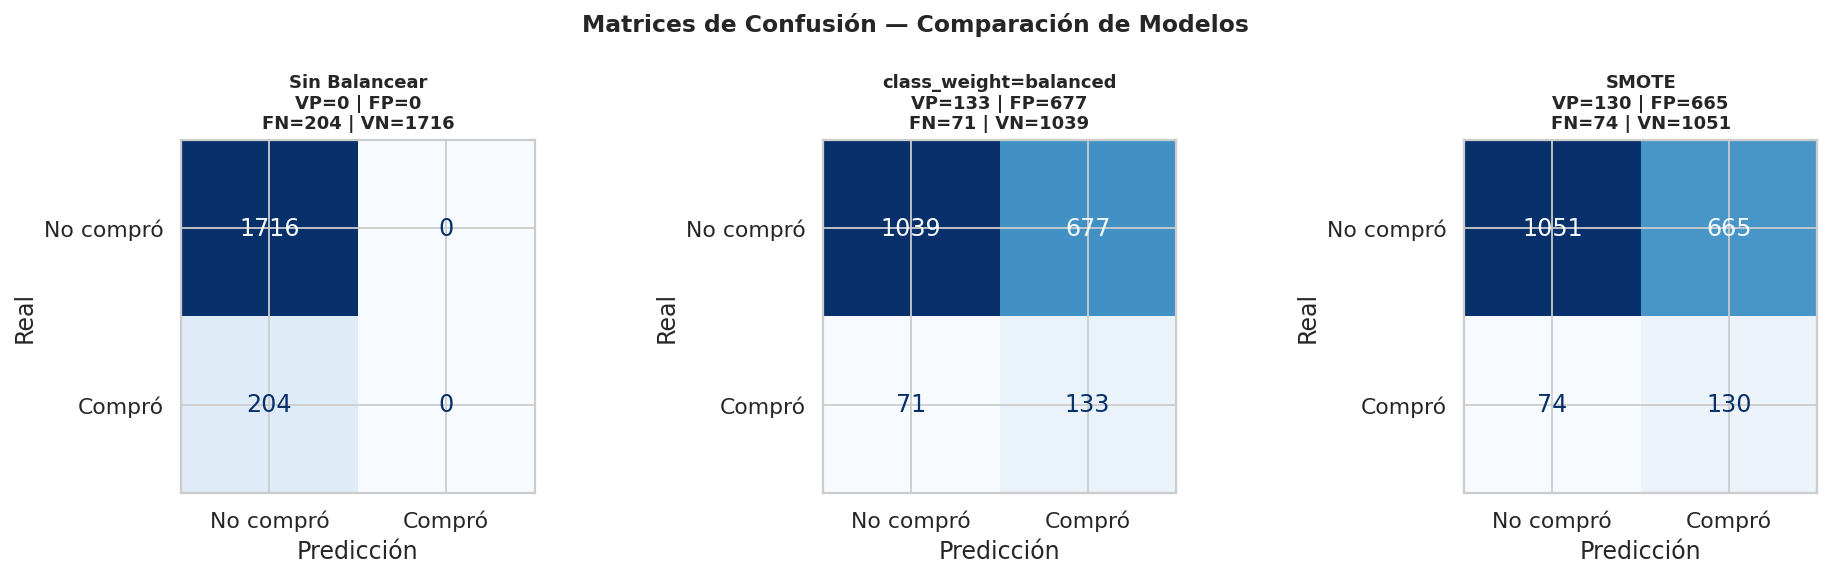

In [1]:
# Matrices de confusión (VP, FP, FN, VN) de los tres modelos

In [1]:
models = {
    'Sin Balancear': (y_pred_ub, y_prob_ub),
    'class_weight=balanced': (y_pred_cw, y_prob_cw),
    'SMOTE': (y_pred_sm, y_prob_sm)
}

def get_metrics(y_true, y_pred, y_proba, name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Modelo': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (1)': precision_score(y_true, y_pred, zero_division=0),
        'Recall (1)': recall_score(y_true, y_pred, zero_division=0),
        'F1 (1)': f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'Avg Precision': average_precision_score(y_true, y_proba),
        'Especificidad': tn/(tn+fp),
        'VP': tp, 'FP': fp, 'FN': fn, 'VN': tn
    }

metrics_list = [get_metrics(y_test, yp, ypr, n) for n, (yp, ypr) in models.items()]
metrics_df = pd.DataFrame(metrics_list).set_index('Modelo')

print('=== TABLA COMPARATIVA DE MÉTRICAS ===')
num_m = ['Accuracy','Precision (1)','Recall (1)','F1 (1)','AUC-ROC','Avg Precision','Especificidad']
print(metrics_df[num_m].round(4).to_string())
print()
print('=== CONTEOS EN MATRIZ DE CONFUSIÓN ===')
print(metrics_df[['VP','FP','FN','VN']].to_string())

=== TABLA COMPARATIVA DE MÉTRICAS ===
                       Accuracy  Precision (1)  Recall (1)  F1 (1)  AUC-ROC  Avg Precision  Especificidad
Modelo                                                                                                     
Sin Balancear            0.8938         0.0000      0.0000  0.0000   0.6832         0.2054         1.0000
class_weight=balanced    0.6104         0.1642      0.6520  0.2623   0.6825         0.2048         0.6055
SMOTE                    0.6151         0.1635      0.6373  0.2603   0.6751         0.2053         0.6125

=== CONTEOS EN MATRIZ DE CONFUSIÓN ===
                        VP   FP   FN    VN
Modelo                                    
Sin Balancear            0    0  204  1716
class_weight=balanced  133  677   71  1039
SMOTE                  130  665   74  1051


### 6.2 Curvas ROC y Precision-Recall

> El AUC-ROC (~0.68) es **similar en los tres modelos** — el balanceo mejora el *threshold* de decisión pero no la capacidad discriminativa del modelo en sí.

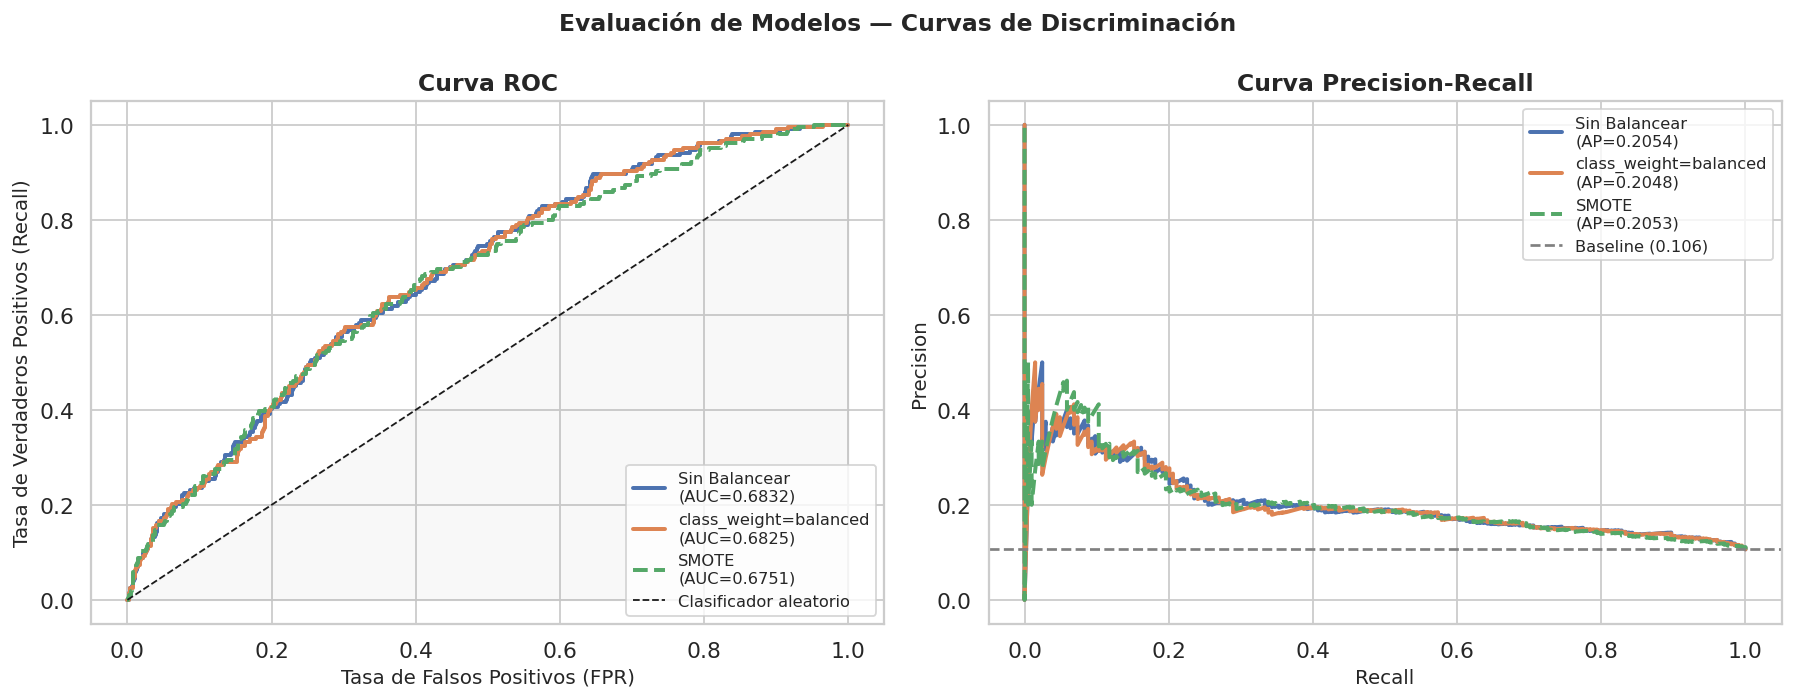

In [1]:
# Curvas ROC y Precision-Recall

### 6.3 Tabla visual de métricas

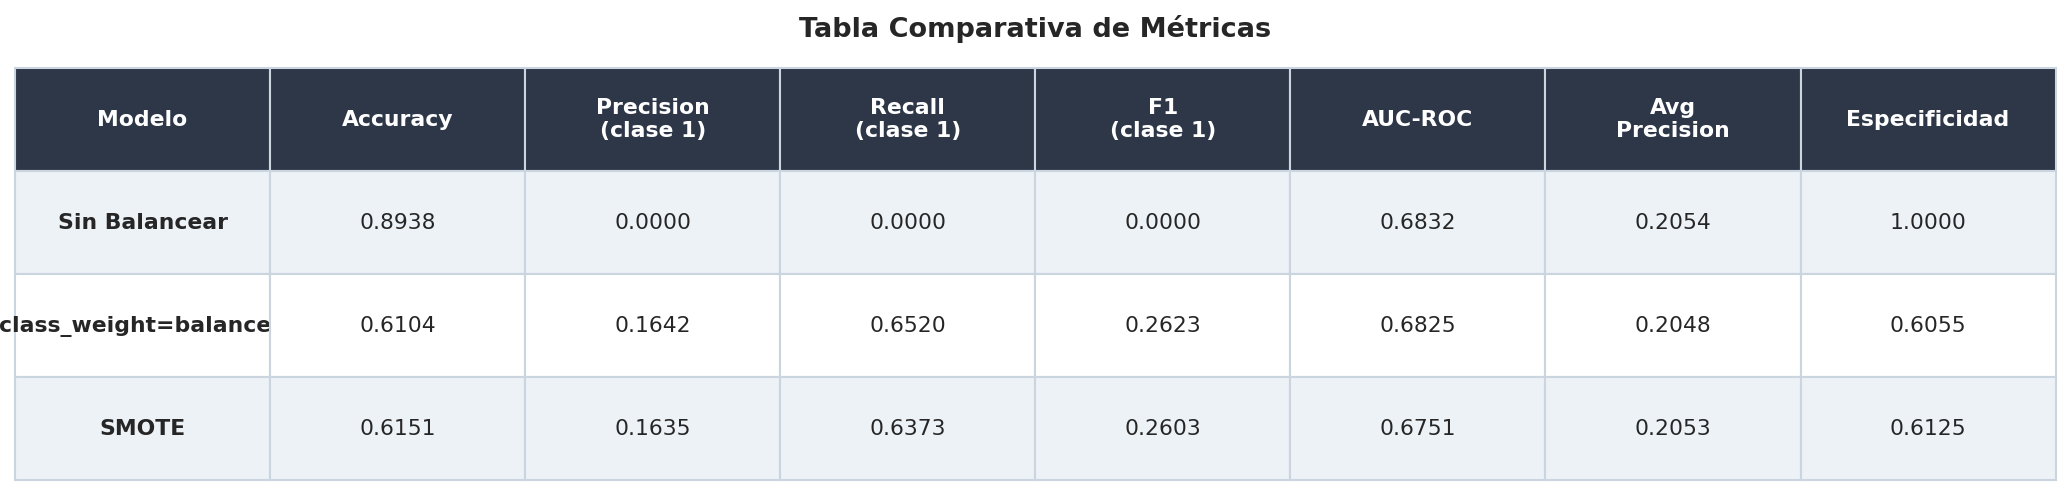

In [1]:
# Tabla comparativa visual

## 7. Interpretación de Coeficientes y Odds Ratios

### ¿Cómo interpretar?
- **Coeficiente β**: cambio en el log-odds por unidad de incremento en la variable (cuando las demás se mantienen constantes)
- **Odds Ratio = exp(β)**: 
  - OR > 1 → la variable **aumenta** la probabilidad de compra
  - OR < 1 → la variable **disminuye** la probabilidad de compra
  - OR = 1 → sin efecto

### Hallazgos clave del modelo balanceado:
| Variable | OR | Interpretación |
|----------|-----|----------------|
| `edad` | 1.22 | A mayor edad, más probable que compre |
| `internal` | 1.12 | Tener plan internacional asociado a más compra |
| `residen` | 1.12 | Más personas en el hogar → más probable compra |
| `noticias` | 0.76 | Suscripción a periódico → menos probable compra |
| `ingcat` | 0.76 | Mayor categoría de ingreso → menos probable compra |
| `direcc` | 0.82 | Más años en la dirección → menos probable compra |

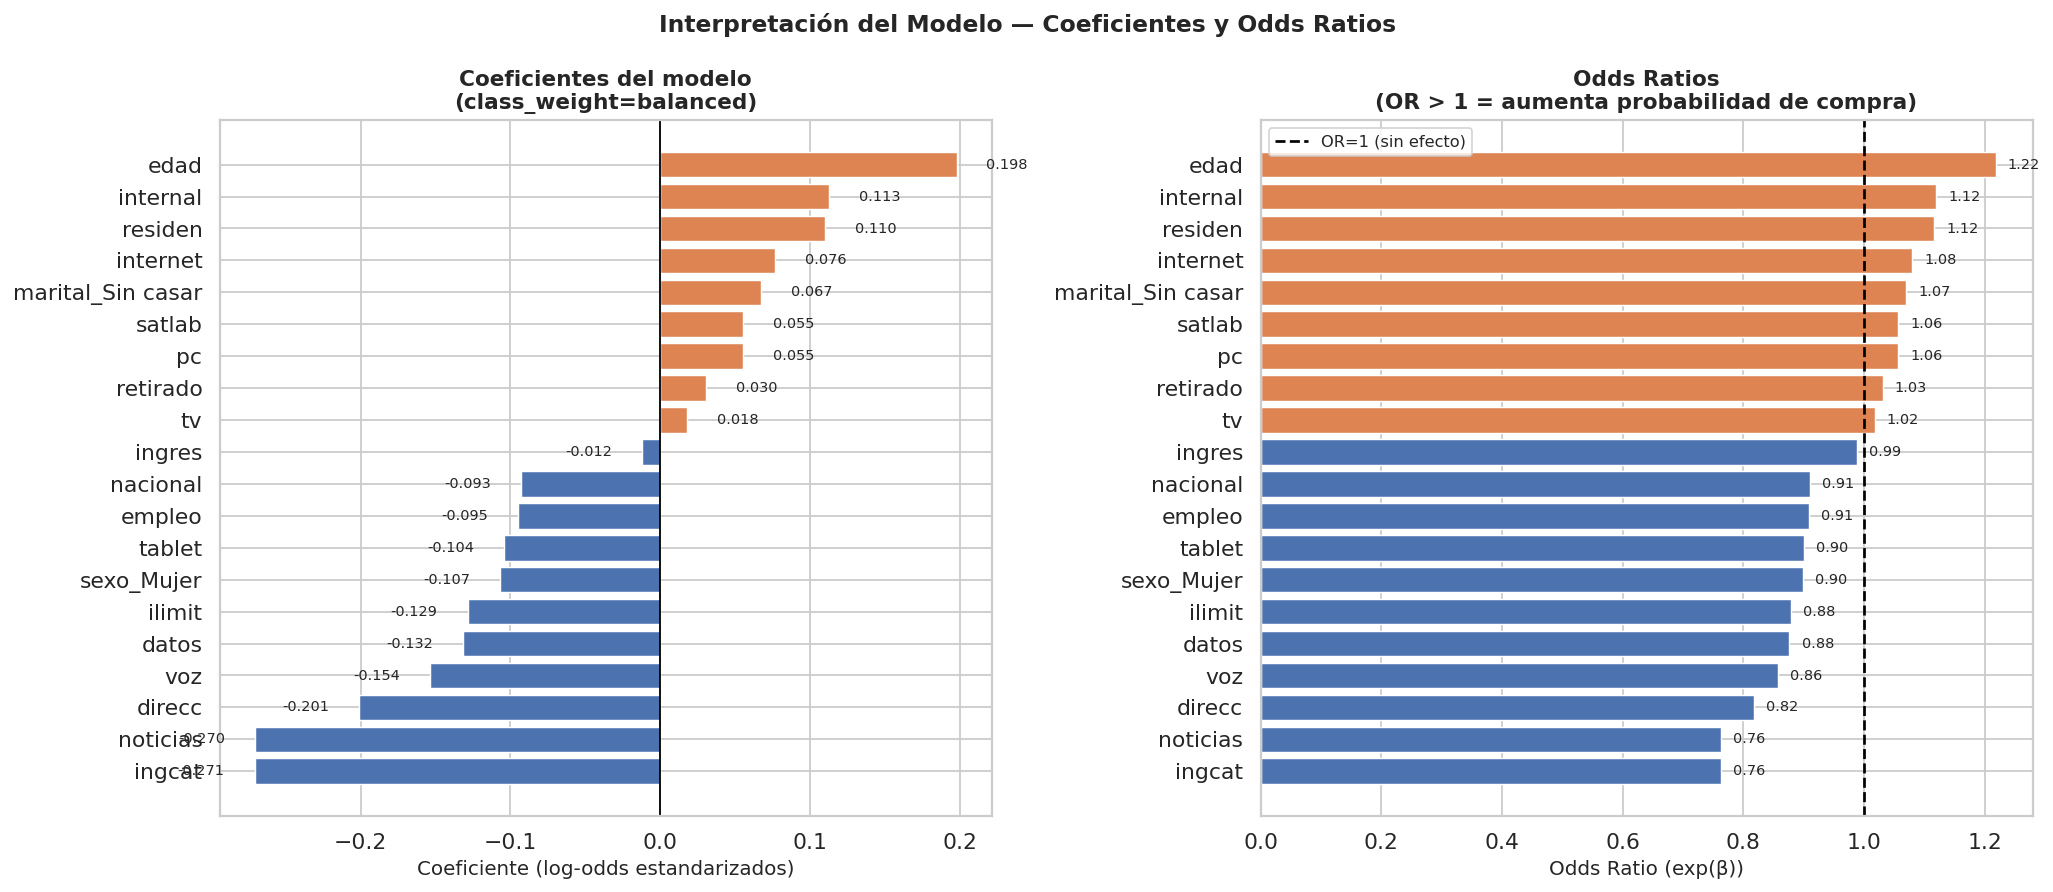

In [1]:
# Coeficientes y Odds Ratios del modelo balanceado

## 8. Análisis del Umbral de Decisión

> El umbral por defecto es **0.5**, pero con clases desbalanceadas suele ser subóptimo. Desplazar el umbral a la baja aumenta el recall a costa de la precision.

Umbral óptimo según F1: 0.1063
F1 con umbral 0.50:     0.2623
F1 con umbral óptimo:   0.2623

Recall con umbral óptimo: 0.6520
Precision con umbral óptimo: 0.1642


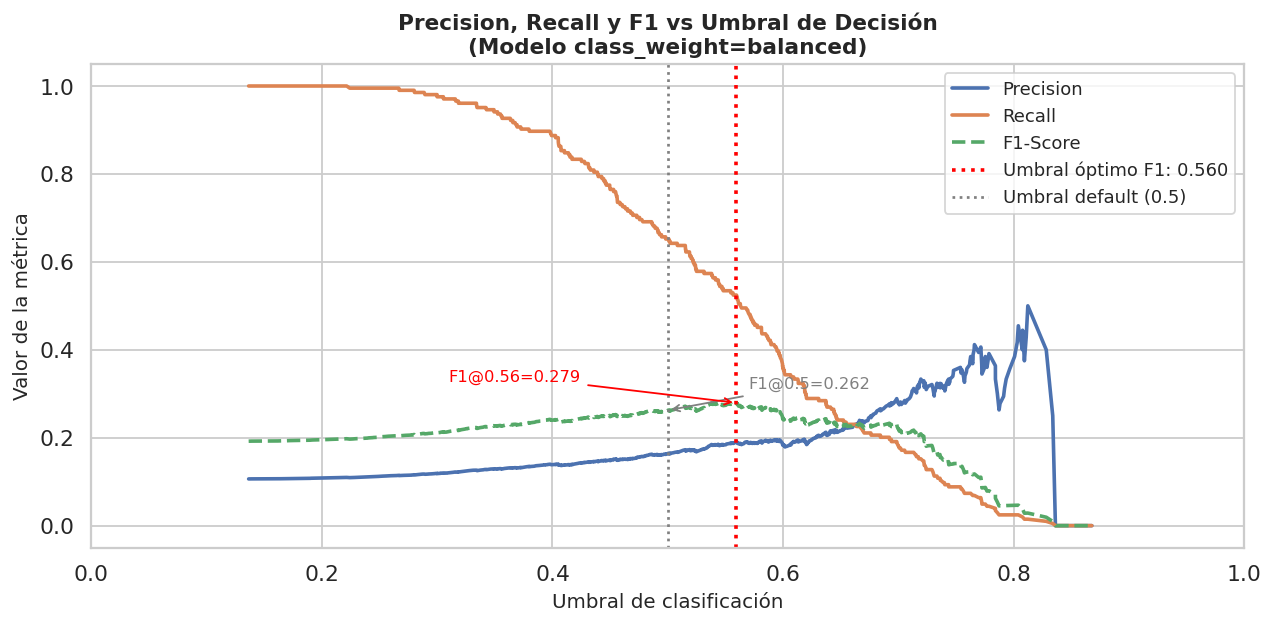

In [1]:
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, y_prob_cw)
f1_arr = 2 * prec_arr * rec_arr / (prec_arr + rec_arr + 1e-10)
best_idx = np.argmax(f1_arr[:-1])
best_thr = thresh_arr[best_idx]

print(f'Umbral óptimo según F1: {best_thr:.4f}')
print(f'F1 con umbral 0.50:     {f1_score(y_test, (y_prob_cw >= 0.50).astype(int)):.4f}')
print(f'F1 con umbral óptimo:   {f1_arr[best_idx]:.4f}')
print()
y_pred_opt = (y_prob_cw >= best_thr).astype(int)
print(f'Recall con umbral óptimo: {recall_score(y_test, y_pred_opt):.4f}')
print(f'Precision con umbral óptimo: {precision_score(y_test, y_pred_opt, zero_division=0):.4f}')

## 9. Validación Cruzada Estratificada (5-Fold)

> `StratifiedKFold` preserva la proporción de clases en cada fold — esencial con datasets desbalanceados.

=== VALIDACIÓN CRUZADA 5-FOLD — AUC-ROC ===
  Sin Balancear            : 0.6623 ± 0.0091
  Scores por fold: [0.6574 0.6683 0.6632 0.6493 0.6734]

  class_weight=balanced    : 0.6621 ± 0.0090
  Scores por fold: [0.6569 0.6681 0.6631 0.6492 0.6732]

  SMOTE                    : 0.6595 ± 0.0120
  Scores por fold: [0.6539 0.6773 0.6569 0.6371 0.6722]



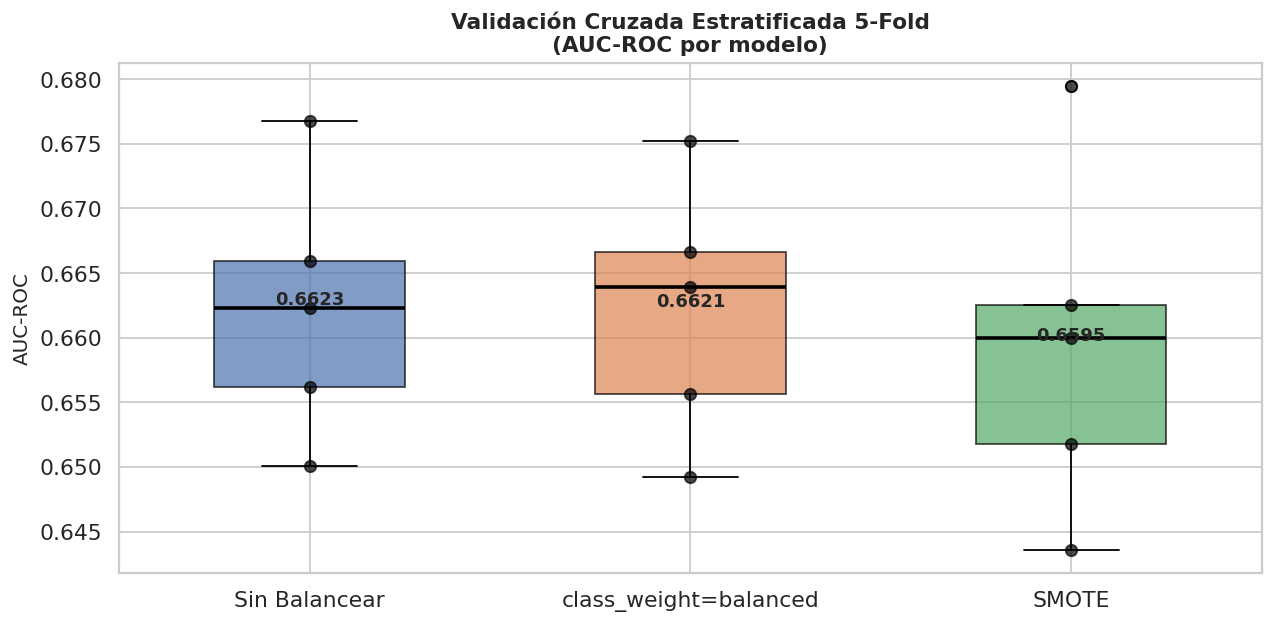

In [1]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('=== VALIDACIÓN CRUZADA 5-FOLD — AUC-ROC ===')
for name, pipe in [('Sin Balancear', pipe_unbal),
                   ('class_weight=balanced', pipe_cw),
                   ('SMOTE', pipe_smote)]:
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'  {name:25s}: {scores.mean():.4f} ± {scores.std():.4f}')
    print(f'  Scores por fold: {np.round(scores, 4)}')
    print()

## 10. Resumen Conceptual — Guía para el Quiz

---

### 🔵 Regresión Logística: fundamentos

**¿Qué modela?** La probabilidad de pertenecer a la clase positiva:
$$P(y=1|X) = \sigma(\beta_0 + \beta_1 x_1 + \dots + \beta_p x_p) = \frac{1}{1+e^{-z}}$$

**Función sigmoide:** transforma cualquier valor real → [0,1]

**Log-odds (logit):** $\log\frac{P}{1-P} = \beta_0 + \beta_1 x_1 + \dots$

**Umbral de decisión:** Si $P(y=1|X) \geq 0.5$ → predice clase 1 (ajustable)

---

### 🔵 Supuestos del modelo
1. Variable dependiente **binaria**
2. Linealidad entre predictores y el **log-odds** (no entre X e y)
3. **Sin multicolinealidad** severa entre predictores
4. Tamaño de muestra suficiente (*rule of thumb*: ≥10 eventos por predictor)
5. **Sin outliers extremos** (afectan los coeficientes)

---

### 🔵 Problema del desbalance de clases

| Síntoma | Consecuencia |
|---------|-------------|
| Alta accuracy (89%) | Modelo predice siempre la clase mayoritaria |
| Recall=0 en clase 1 | No detecta ningún comprador real |
| F1≈0 en clase 1 | Modelo inútil para el objetivo de negocio |

**Técnica 1: `class_weight='balanced'`**
- Asigna pesos $w_i = n/(k \cdot n_i)$ inversamente proporcionales a la frecuencia
- Penaliza más los errores en la clase minoritaria
- Ventaja: simple, sin modificar los datos
- No cambia el AUC, sí cambia el threshold efectivo

**Técnica 2: SMOTE**
- Genera puntos sintéticos interpolando vecinos de la clase minoritaria
- Modifica físicamente el conjunto de entrenamiento
- Se aplica **SOLO en train**, nunca en test
- Similar rendimiento al class_weight en este dataset

---

### 🔵 Métricas: ¿cuándo usar cuál?

| Métrica | Fórmula | Cuándo priorizar |
|---------|---------|-----------------|
| **Accuracy** | (VP+VN)/Total | Clases balanceadas |
| **Precision** | VP/(VP+FP) | Costo alto de falso positivo |
| **Recall/Sensibilidad** | VP/(VP+FN) | Costo alto de falso negativo |
| **F1-Score** | 2·P·R/(P+R) | Balance precision/recall |
| **AUC-ROC** | Área bajo curva ROC | Ranking/comparación independiente del umbral |
| **Especificidad** | VN/(VN+FP) | Correcta clasificación de negativos |

**En este caso (marketing):** Se prioriza **Recall** (detectar compradores) y **F1**.

---

### 🔵 Interpretación de coeficientes (modelo este dataset)

- **`edad` (OR=1.22):** Por cada año adicional, los odds de compra aumentan 22%
- **`noticias` (OR=0.76):** Estar suscrito a periódico reduce los odds de compra 24%
- **`internal` (OR=1.12):** Tener plan internacional aumenta los odds 12%
- **`direcc` (OR=0.82):** Más años en la misma dirección → menos probable compra

---

### 🔵 Resultados del dataset

| Modelo | Accuracy | Recall(1) | F1(1) | AUC-ROC |
|--------|----------|-----------|-------|---------|
| Sin Balancear | **0.8938** | 0.0000 | 0.0000 | 0.6832 |
| class_weight=balanced | 0.6104 | **0.6520** | **0.2623** | 0.6825 |
| SMOTE | 0.6151 | 0.6373 | 0.2603 | 0.6751 |

**Conclusión:** Los modelos balanceados tienen menor accuracy pero son SUPERIORES para el objetivo real (detectar compradores). El AUC-ROC es prácticamente igual en los tres → el desbalance no afecta la capacidad discriminativa inherente del modelo, sino el umbral de decisión.

In [1]:
# Resumen final ejecutable
print('='*65)
print('RESUMEN FINAL'.center(65))
print('='*65)
num_m2 = ['Accuracy','Precision (1)','Recall (1)','F1 (1)','AUC-ROC']
print(metrics_df[num_m2].round(4).to_string())
print()
best_recall = metrics_df['Recall (1)'].idxmax()
best_f1     = metrics_df['F1 (1)'].idxmax()
best_auc    = metrics_df['AUC-ROC'].idxmax()
print(f'🏆 Mejor Recall (clase 1): {best_recall}')
print(f'🏆 Mejor F1 (clase 1):     {best_f1}')
print(f'🏆 Mejor AUC-ROC:          {best_auc}')
print()
print('💡 CONCLUSIÓN: Los modelos balanceados sacrifican accuracy global')
print('   pero son superiores para identificar compradores (objetivo real).')
print('   En contexto de marketing, preferir RECALL y F1 sobre accuracy.')

                      RESUMEN FINAL                              
                       Accuracy  Precision (1)  Recall (1)  F1 (1)  AUC-ROC
Modelo                                                                       
Sin Balancear            0.8938         0.0000      0.0000  0.0000   0.6832
class_weight=balanced    0.6104         0.1642      0.6520  0.2623   0.6825
SMOTE                    0.6151         0.1635      0.6373  0.2603   0.6751

🏆 Mejor Recall (clase 1): class_weight=balanced
🏆 Mejor F1 (clase 1):     class_weight=balanced
🏆 Mejor AUC-ROC:          Sin Balancear

💡 CONCLUSIÓN: Los modelos balanceados sacrifican accuracy global
   pero son superiores para identificar compradores (objetivo real).
   En contexto de marketing, preferir RECALL y F1 sobre accuracy.
